<a href="https://colab.research.google.com/github/engEugene/ml-formative1-assignment/blob/main/PCA_Formative_1%5BGroup_50%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
#load data from the csv
df = pd.read_csv("ObservationData_lavlqce.csv")
print("Original data shape", df.shape)
df.head()

Original data shape (2322, 31)


,Country,Year,Real per Capita GDP Growth Rate (annual %),Real GDP growth (annual %),"Gross domestic product, (constant prices US$)","Gross domestic product, current prices (current US$)",Final consumption expenditure (current US$),General government final consumption expenditure (current US$),Household final consumption expenditure (current US$),Gross capital formation (current US$),...,Imports of goods and services (% of GDP),"Central government, Fiscal Balance (Current US $)","Central government, total revenue and grants (Current US $)","Central government, total expenditure and net lending (Current US $)","Central government, Fiscal Balance (% of GDP)","Central government, total revenue and grants (% of GDP)","Central government, total expenditure and net lending (% of GDP)","Current account balance (Net, BoP, cur. US$)",Current account balance (As % of GDP),"Inflation, consumer prices (annual %)"
0,Malawi,1980,NaN,NaN,3038.14,2236.36,1104.30,238.76,865.54,306.24,...,21.48,-142.96,298.61,441.57,-6.39,13.35,19.75,-207.07,-9.26,NaN
1,Malawi,1981,-13.06,-10.81,2709.74,2236.40,1091.26,221.16,870.10,218.14,...,17.41,-133.47,276.61,410.09,-5.97,12.37,18.34,-86.71,-3.88,12.01
2,Malawi,1982,-0.93,1.44,2748.84,2113.68,1002.45,206.82,795.63,252.58,...,16.10,-119.21,254.71,373.92,-5.64,12.05,17.69,-91.15,-4.31,9.52
3,Malawi,1983,1.56,4.21,2864.70,2203.66,1037.06,200.81,836.26,278.87,...,15.73,-96.80,250.68,347.48,-4.39,11.38,15.77,-103.94,-4.72,13.77
4,Malawi,1984,0.54,3.92,2976.95,2157.88,1028.95,189.62,839.34,155.58,...,14.79,-78.94,239.30,318.24,-3.66,11.09,14.75,3.88,0.18,19.74


In [ ]:
#select numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
x = df[numeric_columns].copy()
x = x.fillna(x.mean())
print("Numeric data shape:", x.shape)
print("Number of numeric features:", x.shape[1])

Numeric data shape: (2322, 30)
Number of numeric features: 30


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

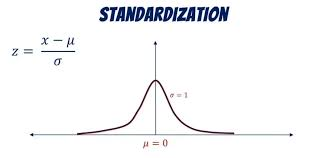


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = np.mean (x, axis=0)
std = np.std(x,axis=0)
std = np.where(std == 0,1,std)
standardized_data = (x - mean) / std  # Do not use sklearn
standardized_data = standardized_data.values
standardized_data[:5]  # Display the first few rows of standardized data

array([[-1.69222822,  0.        ,  0.        , -0.38404956, -0.36199338,
        -0.36900468, -0.36743558, -0.35601898, -0.39395488, -0.40158995,
        -0.3288848 , -0.41302626, -0.43432464, -1.36824738, -0.60878942,
        -1.23212277, -0.67919714, -0.87038706,  0.0258651 , -0.74542515,
        -0.71313751,  0.20872162, -0.3931922 , -0.38211177, -0.32281631,
        -0.74000136, -0.43753575,  0.06292451, -0.37755419,  0.        ],
       [-1.61164593, -1.78287028, -1.75654968, -0.38926399, -0.36199267,
        -0.36929566, -0.36962615, -0.35589947, -0.40100004, -0.40140123,
        -0.34394684, -0.41231193, -0.44078181, -1.39340534, -0.71780174,
        -1.22258627, -1.04890016, -0.86340193, -0.46401486, -0.72226683,
        -0.88905448,  0.21127501, -0.39498819, -0.38425679, -0.27020336,
        -0.82673545, -0.54702996,  0.09663435,  0.16402705, -0.0134958 ],
       [-1.53106363, -0.24933395, -0.25966898, -0.38864315, -0.36416333,
        -0.37127737, -0.37141097, -0.35785112, -0

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)  # Calculate covariance matrix
print("Coveriance matrix shaope", cov_matrix.shape)

Coveriance matrix shaope (30, 30)


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)  # Perform eigendecomposition
print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)
eigenvalues, eigenvectors


Eigenvalues shape: (30,)
Eigenvectors shape: (30, 30)


(array([1.11137468e+01, 3.99216849e+00, 2.83756053e+00, 2.16168759e+00,
        1.57125981e+00, 1.43758321e+00, 1.22924642e+00, 9.63346304e-01,
        8.86635673e-01, 7.44510417e-01, 6.27821016e-01, 4.96035315e-01,
        4.75160510e-01, 3.99373577e-01, 3.36819634e-01, 2.06237340e-01,
        1.61345634e-01, 1.05483020e-01, 7.29575960e-02, 6.08429355e-02,
        4.85027456e-02, 3.44290744e-02, 2.00803790e-02, 1.12323355e-02,
        9.36483347e-03, 7.04970856e-03, 1.63926254e-03, 8.05275842e-04,
        1.54342293e-08, 5.06529054e-15]),
 array([[ 8.32159872e-02, -1.18604251e-01,  5.19964845e-02,
          2.34013387e-01, -6.87168277e-02, -3.18100348e-01,
          1.38044480e-01, -9.73419304e-02, -2.31992785e-01,
         -7.96195059e-01, -3.62909403e-04,  1.85754376e-01,
          2.03855870e-02, -1.98151323e-01,  4.18517851e-02,
         -5.03900382e-02,  3.33943066e-02, -1.20289790e-01,
         -6.08822161e-02,  2.41721641e-02, -1.07123821e-02,
         -1.19511116e-02, -9.68341




























































### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted eigenvalues (first 5):", sorted_eigenvalues[:5])
print("Sorted eigenvectors (first 5 columns):\n", sorted_eigenvectors[:, :5])

Sorted eigenvalues (first 5): [11.1137468   3.99216849  2.83756053  2.16168759  1.57125981]
Sorted eigenvectors (first 5 columns):
 [[ 8.32159872e-02 -1.18604251e-01  5.19964845e-02  2.34013387e-01
  -6.87168277e-02]
 [ 3.89582662e-03 -8.66261261e-02 -2.87601419e-01  4.50612119e-01
   1.74201740e-01]
 [-7.42931345e-04 -7.16085756e-02 -2.88741115e-01  4.52130613e-01
   1.98291485e-01]
 [ 2.81303340e-01  5.35531776e-02 -1.68803547e-02  9.54572942e-03
  -3.52645159e-02]
 [ 2.88829901e-01  5.73486237e-02 -3.69769016e-03  3.86880471e-02
  -2.59455453e-02]
 [ 2.85794020e-01  5.35110836e-02  4.53597529e-02  5.87600754e-02
  -2.56489085e-02]
 [ 2.82090129e-01 -1.06057064e-02 -2.06842364e-04 -2.90487927e-02
  -3.96849534e-02]
 [ 2.76260599e-01  6.50804989e-02  5.33173887e-02  7.51286833e-02
  -2.17678950e-02]
 [ 2.86195334e-01  9.01610949e-04 -2.16232332e-02  2.57505941e-02
   2.15424805e-02]
 [ 2.77487834e-01  6.13195743e-03 -1.70134242e-03  5.29651031e-03
   6.52525877e-02]
 [ 2.41890948e-01 

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = 2  # Decide on the number of principal components to keep
# Convert to numpy array if it's still a DataFrame
standardized_array = np.array(standardized_data)

principal_components = sorted_eigenvectors[:, :num_components]
reduced_data = np.dot(standardized_array, principal_components)
reduced_data[:5]

array([[-1.47897086,  1.92545585],
       [-1.48738764,  2.71077104],
       [-1.45392258,  2.40905471],
       [-1.45023651,  2.45564939],
       [-1.49404628,  2.88341927]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (2322, 2)


array([[-1.47897086,  1.92545585],
       [-1.48738764,  2.71077104],
       [-1.45392258,  2.40905471],
       [-1.45023651,  2.45564939],
       [-1.49404628,  2.88341927]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

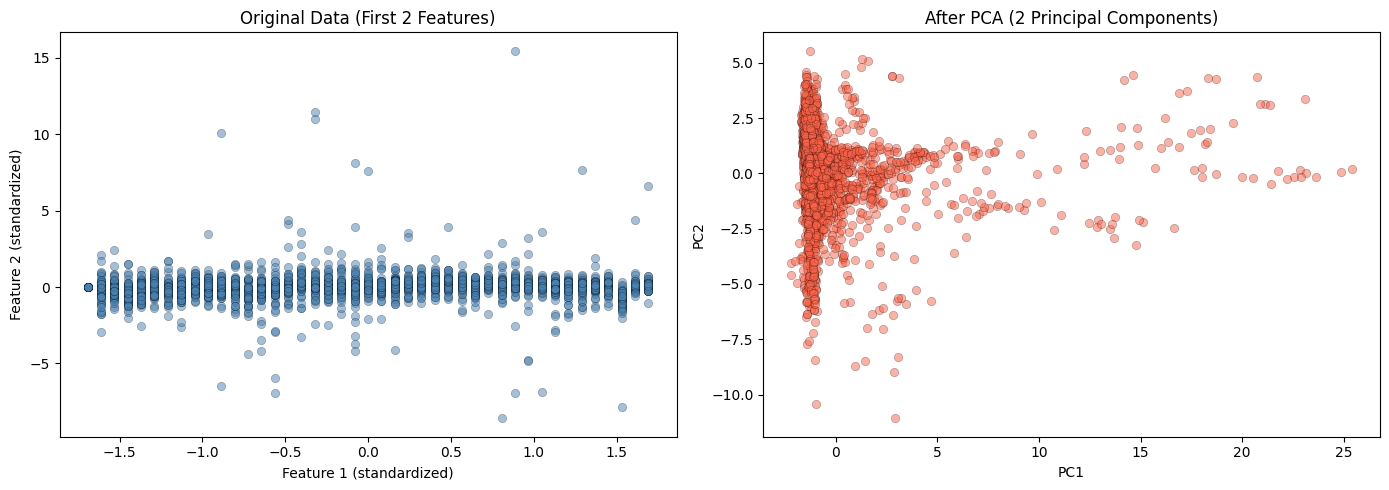

In [ ]:
# Step 8: Visualize Before and After PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot original data (first two features for simplicity)
axes[0].scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
axes[0].set_title('Original Data (First 2 Features)')
axes[0].set_xlabel('Feature 1 (standardized)')
axes[0].set_ylabel('Feature 2 (standardized)')

# Plot reduced data after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, color='tomato', edgecolors='k', linewidths=0.3)
axes[1].set_title('After PCA (2 Principal Components)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
